# B-6511502A | One-Class SVM | Treino Mai/2022–Fev/2023 | 14 sensores

Visualiza anomalias detectadas pelo One-Class SVM treinado na série disponível.

- **Treino**: Mai/2022 – Fev/2023
- **Val**: Fev/2023 – Mai/2023
- **Teste**: 05/Mai – 13/Mai/2023 (pré-falha)
- **Falha**: Quebra das lâminas do acoplamento (15/Mai/2023)
- **Sensores**: Corrente, Pressão Sucção, Pressão Descarga, Deslocamento Axial LNA 1/2, Temperatura Motor LNA, 8x Vibração Radial (BB e Motor, LA e LNA, 0° e 90°)

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clearml import Task

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists()),
    Path.cwd(),
)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing

In [2]:
# ==============================
# Configuracao
# ==============================
TASK_ID = 'ea82a7bac7814814a03cf2f44bd7c603'
EQUIPMENT_ID = 'B-6511502A'
USE_FULL_SCORES = True

# Eventos
EVENT_DATE_F1 = '2023-05-15 00:00'
EVENT_LABEL_F1 = 'Falha: Quebra das lâminas do acoplamento (15/Mai/2023)'

EVENT_TS_F1 = pd.Timestamp(EVENT_DATE_F1)
WINDOW_F1_ZOOM_START = EVENT_TS_F1 - pd.Timedelta(days=10)
WINDOW_F1_ZOOM_END = EVENT_TS_F1

# Calibracao sobre a janela de validacao (Fev-Mai/2023)
AUTO_USE_CALIBRATED_SENSITIVITY = True
SENSITIVITY_PRESET = 'custom'  # 'conservative' | 'balanced' | 'sensitive' | 'custom'
CALIB_START = '2023-02-28'
CALIB_END = '2023-05-04'
CALIB_PERCENTILES = [99, 99.5, 99.7, 99.9]
CALIB_PERSISTENCE_GRID = [(3, 5), (4, 6), (5, 8)]
TARGET_ALERTS_PER_DAY = 0.1

# Visualizacao
PLOT_MODE = 'separated'  # 'separated' | 'consolidated'
SAVE_PLOTS = False

OUTPUT_DPI = 180
FIGSIZE_WIDTH = 12
PANEL_HEIGHT = 2.5

In [3]:
def _normalize_scores_df(scores):
    if not isinstance(scores, pd.DataFrame):
        raise TypeError(f'artifact de scores deve ser DataFrame, veio: {type(scores)}')
    required_cols = {'reconstruction_error', 'is_anomaly'}
    missing = required_cols - set(scores.columns)
    if missing:
        raise ValueError(f'colunas faltando em scores: {missing}')
    s = scores.copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    return s[['reconstruction_error', 'is_anomaly']]


def _load_local_artifacts(task_id: str, equipment_id: str, use_full_scores: bool = True):
    import pickle
    local_dir = PROJECT_ROOT / 'artifacts_local' / f'{task_id}_{equipment_id}'
    if not local_dir.exists():
        return None
    results_path = local_dir / 'results.pkl'
    if not results_path.exists():
        return None
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
    if use_full_scores and (local_dir / 'full_scores.parquet').exists():
        scores = pd.read_parquet(local_dir / 'full_scores.parquet')
        score_artifact_name = 'full_scores'
    elif (local_dir / 'test_scores.parquet').exists():
        scores = pd.read_parquet(local_dir / 'test_scores.parquet')
        score_artifact_name = 'test_scores'
    else:
        return None
    return results, scores, score_artifact_name


def load_task_outputs(task_id: str, use_full_scores: bool = True):
    task = Task.get_task(task_id=task_id)

    local = _load_local_artifacts(task_id, EQUIPMENT_ID, use_full_scores)
    if local is not None:
        results, scores, score_artifact_name = local
        scores = _normalize_scores_df(scores)
        threshold = float(results['threshold'])
        print(f'[INFO] Artefatos carregados localmente (artifacts_local/{task_id}_{EQUIPMENT_ID})')
        return task, results, threshold, scores, score_artifact_name

    if 'results' not in task.artifacts:
        raise KeyError('artifact results nao encontrado na task (nem local nem ClearML)')
    results = task.artifacts['results'].get()
    if 'threshold' not in results:
        raise KeyError('campo threshold nao encontrado em results')
    threshold = float(results['threshold'])
    if use_full_scores and 'full_scores' in task.artifacts:
        score_artifact_name = 'full_scores'
    elif 'test_scores' in task.artifacts:
        score_artifact_name = 'test_scores'
    elif 'full_scores' in task.artifacts:
        score_artifact_name = 'full_scores'
    else:
        raise KeyError('nenhum artifact de score disponivel (full_scores/test_scores)')
    scores = _normalize_scores_df(task.artifacts[score_artifact_name].get())
    return task, results, threshold, scores, score_artifact_name


def load_plot_base(equipment_id: str):
    config = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)
    pre_steps = config.pre_split_steps
    if pre_steps:
        df_base, _, _ = run_preprocessing(df_raw, pre_steps, fitted_scaler=None)
    else:
        df_base = df_raw
    df_base = df_base.sort_index()
    df_base.index = pd.to_datetime(df_base.index)
    return df_base, config


def slice_window(df_base, scores, window_start, window_end):
    dfw = df_base.loc[pd.Timestamp(window_start):pd.Timestamp(window_end)].copy()
    sw = scores.loc[pd.Timestamp(window_start):pd.Timestamp(window_end)].copy()
    common_idx = dfw.index.intersection(sw.index)
    if len(common_idx) == 0:
        raise ValueError(f'nao ha intersecao de timestamps na janela {window_start}..{window_end}')
    return dfw.loc[common_idx], sw.loc[common_idx]


def print_preprocessing_confirmation(config):
    print('Preprocessamento aplicado para score/predict:')
    print('  1) Pre-split (base bruta):')
    for step in config.pre_split_steps:
        print(f'     - {step}')
    print('  2) Pos-split/predict (modelo): clip + normalize(robust),')
    print('     usando clip_bounds e scaler ajustados no treino.')


def persistence_filter(flags: pd.Series, k: int, n: int) -> pd.Series:
    if k == 1 and n == 1:
        return flags.astype(bool)
    roll = flags.astype(int).rolling(window=n, min_periods=n).sum()
    return (roll >= k).fillna(False).astype(bool)


def recommend_sensitivity(scores: pd.DataFrame, calib_start: str, calib_end: str):
    calib = scores.loc[pd.Timestamp(calib_start):pd.Timestamp(calib_end)].copy()
    if calib.empty:
        raise ValueError(f'janela de calibracao vazia: {calib_start}..{calib_end}')
    rows = []
    for p in CALIB_PERCENTILES:
        thr = float(np.percentile(calib['reconstruction_error'].values, p))
        for (k, n) in CALIB_PERSISTENCE_GRID:
            flags = persistence_filter(scores['reconstruction_error'] > thr, k=k, n=n)
            n_days = max((scores.index.max().normalize() - scores.index.min().normalize()).days + 1, 1)
            alerts_per_day = float(flags.sum()) / float(n_days)
            rows.append({
                'percentile': float(p), 'threshold': float(thr), 'k': int(k), 'n': int(n),
                'alerts_per_day': alerts_per_day,
                'distance_to_target': abs(alerts_per_day - TARGET_ALERTS_PER_DAY),
            })
    calib_df = pd.DataFrame(rows).sort_values(['distance_to_target', 'alerts_per_day']).reset_index(drop=True)
    best = calib_df.iloc[0]
    return {
        'threshold': float(best['threshold']), 'k': int(best['k']), 'n': int(best['n']),
        'percentile': float(best['percentile']), 'alerts_per_day': float(best['alerts_per_day']),
        'table': calib_df,
    }

In [4]:
def plot_anomaly_panels(
    df_window, scores_window, threshold_flags, anomaly_flags,
    threshold, threshold_label, event_date, event_label, title,
    output_path=None, dpi=180, plot_mode='separated', save_plots=False, score_label='Score de Anomalia',
):
    plt.style.use('seaborn-v0_8-whitegrid')
    mode = str(plot_mode).strip().lower()
    if mode not in {'separated', 'consolidated'}:
        raise ValueError("plot_mode invalido. Use: 'separated' ou 'consolidated'")

    saved_paths = []
    sensors = list(df_window.columns)
    anomaly_idx = scores_window.index[anomaly_flags]

    def maybe_save(fig, suffix=None):
        if not save_plots:
            return None
        out = Path(output_path)
        out.parent.mkdir(parents=True, exist_ok=True)
        target = out.with_name(f"{out.stem}_{suffix}{out.suffix}") if suffix else out
        fig.savefig(target, dpi=dpi, bbox_inches='tight')
        saved_paths.append(target)

    if mode == 'separated':
        for col in sensors:
            fig, ax = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.4))
            ax.plot(df_window.index, df_window[col], color='steelblue', linewidth=1.0, alpha=0.85, label=f'Serie: {col}')
            anom_vals = df_window[col].reindex(anomaly_idx).dropna()
            if not anom_vals.empty:
                ax.scatter(anom_vals.index, anom_vals.values, s=28, color='red', edgecolor='none', zorder=4, label='Anomalia')
            ax.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
            ax.set_ylabel(col, fontsize=9)
            ax.set_xlabel('Tempo', fontsize=10)
            ax.tick_params(axis='both', labelsize=8)
            ax.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)
            fig.suptitle(f'{title} | {col}', fontsize=14, fontweight='bold', y=0.995)
            fig.tight_layout(rect=[0, 0, 1, 0.96])
            slug = ''.join(ch if ch.isalnum() else '_' for ch in str(col)).strip('_').lower()
            maybe_save(fig, suffix=f'sensor_{slug}' if slug else 'sensor')
            plt.show()

        fig_s, ax_s = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.6))
        x = scores_window.index
        y = scores_window['reconstruction_error']
        ax_s.plot(x, y, color='teal', linewidth=1.1, label=score_label)
        ax_s.axhline(threshold, color='red', linestyle='--', linewidth=1.3, label=threshold_label)
        ax_s.fill_between(x, threshold, y, where=(y > threshold), color='red', alpha=0.18)
        idx_thr = scores_window.index[threshold_flags]
        if len(idx_thr) > 0:
            ax_s.scatter(idx_thr, scores_window.loc[idx_thr, 'reconstruction_error'], s=10, color='orange', alpha=0.45, label='Cruzamento bruto', zorder=3)
        idx_pers = scores_window.index[anomaly_flags]
        if len(idx_pers) > 0:
            ax_s.scatter(idx_pers, scores_window.loc[idx_pers, 'reconstruction_error'], s=14, color='red', alpha=0.75, label='Alerta com persistencia', zorder=4)
        ax_s.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
        ax_s.set_ylabel('Score de Anomalia', fontsize=9)
        ax_s.set_xlabel('Tempo', fontsize=10)
        ax_s.tick_params(axis='both', labelsize=8)
        ax_s.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)
        fig_s.suptitle(f'{title} | Score de Anomalia', fontsize=14, fontweight='bold', y=0.995)
        fig_s.tight_layout(rect=[0, 0, 1, 0.96])
        maybe_save(fig_s, suffix='score')
        plt.show()
        return saved_paths

    n_rows = len(sensors) + 1
    fig, axes = plt.subplots(n_rows, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * n_rows), sharex=True,
                             gridspec_kw={'height_ratios': [1] * len(sensors) + [0.95]})
    for i, col in enumerate(sensors):
        ax = axes[i]
        ax.plot(df_window.index, df_window[col], color='steelblue', linewidth=1.0, alpha=0.85, label=f'Serie: {col}')
        anom_vals = df_window[col].reindex(anomaly_idx).dropna()
        if not anom_vals.empty:
            ax.scatter(anom_vals.index, anom_vals.values, s=28, color='red', edgecolor='none', zorder=4, label='Anomalia')
        ax.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
        ax.set_ylabel(col, fontsize=9)
        ax.tick_params(axis='both', labelsize=8)
        ax.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)
    ax_s = axes[-1]
    x = scores_window.index
    y = scores_window['reconstruction_error']
    ax_s.plot(x, y, color='teal', linewidth=1.1, label=score_label)
    ax_s.axhline(threshold, color='red', linestyle='--', linewidth=1.3, label=threshold_label)
    ax_s.fill_between(x, threshold, y, where=(y > threshold), color='red', alpha=0.18)
    idx_thr = scores_window.index[threshold_flags]
    if len(idx_thr) > 0:
        ax_s.scatter(idx_thr, scores_window.loc[idx_thr, 'reconstruction_error'], s=10, color='orange', alpha=0.45, label='Cruzamento bruto', zorder=3)
    idx_pers = scores_window.index[anomaly_flags]
    if len(idx_pers) > 0:
        ax_s.scatter(idx_pers, scores_window.loc[idx_pers, 'reconstruction_error'], s=14, color='red', alpha=0.75, label='Alerta com persistencia', zorder=4)
    ax_s.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
    ax_s.set_ylabel('Score de Anomalia', fontsize=9)
    ax_s.set_xlabel('Tempo', fontsize=10)
    ax_s.tick_params(axis='both', labelsize=8)
    ax_s.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.99])
    maybe_save(fig)
    plt.show()
    return saved_paths

In [5]:
task, results, threshold, scores, score_artifact_name = load_task_outputs(TASK_ID, use_full_scores=USE_FULL_SCORES)
df_base, config = load_plot_base(EQUIPMENT_ID)

print_preprocessing_confirmation(config)
print()
print('Task:', task.id)
print('Artifact de score usado:', score_artifact_name)
print(f'Threshold (results): {threshold:.6f}')
print(f'Scores: {scores.index.min()} .. {scores.index.max()} ({len(scores)} pontos)')

preset = str(SENSITIVITY_PRESET).strip().lower()
eff_percentiles = list(CALIB_PERCENTILES)
eff_grid = list(CALIB_PERSISTENCE_GRID)
eff_target_alerts = float(TARGET_ALERTS_PER_DAY)

if preset == 'conservative':
    eff_percentiles = [99, 99.5, 99.7, 99.9]
    eff_grid = [(3, 5), (4, 6), (5, 8)]
    eff_target_alerts = 0.5
elif preset == 'sensitive':
    eff_percentiles = [95, 97, 98, 99]
    eff_grid = [(1, 1), (2, 3), (3, 5)]
    eff_target_alerts = 4.0
elif preset not in ('balanced', 'custom'):
    raise ValueError('SENSITIVITY_PRESET invalido. Use: conservative, balanced, sensitive ou custom')

print('\nPreset de sensibilidade:', preset)
print('  Janela calibracao:', CALIB_START, '..', CALIB_END)

if AUTO_USE_CALIBRATED_SENSITIVITY:
    CALIB_PERCENTILES = eff_percentiles
    CALIB_PERSISTENCE_GRID = eff_grid
    TARGET_ALERTS_PER_DAY = eff_target_alerts
    sens = recommend_sensitivity(scores, CALIB_START, CALIB_END)
    selected_threshold = float(sens['threshold'])
    selected_k = int(sens['k'])
    selected_n = int(sens['n'])
    threshold_label = f"Limite calibrado (thr={selected_threshold:.4f}, p={sens['percentile']:.1f}, k={selected_k}, n={selected_n})"
    print('\nSensibilidade automatica ativa:')
    print(f'  threshold={selected_threshold:.6f}, p={sens["percentile"]:.1f}, k={selected_k}, n={selected_n}')
    print(f'  Alerts/day estimados: {sens["alerts_per_day"]:.3f}')
else:
    selected_threshold = float(threshold)
    selected_k = 1
    selected_n = 1
    threshold_label = f'Limite (threshold = {selected_threshold:.4f})'
    print('\nUsando threshold original da task.')

Preprocessamento aplicado para score/predict:
  1) Pre-split (base bruta):
     - {'step': 'remove_sensor_errors', 'error_values': [32767.0]}
     - {'step': 'filter_running', 'column': 'CORRENTE ELÉTRICA DO MOTOR', 'threshold': 60.0}
     - {'step': 'remove_transients', 'minutes': 15}
     - {'step': 'resample', 'freq': '5min'}
     - {'step': 'ffill', 'limit': 4}
     - {'step': 'select_features', 'features': ['CORRENTE ELÉTRICA DO MOTOR', 'PRESSÃO SUCÇÃO', 'PRESSÃO DESCARGA', 'DESLOC. AXIAL EIXO BB LNA 1 ZE-50', 'DESLOC. AXIAL EIXO BB LNA 2 ZE-51', 'TEMP. MANCAL LNA MOT TE-07A1/A2', 'VIB. MANCAL RADIAL BB LA 0° VE-50C', 'VIB. MANCAL RADIAL BB LA 90° VE-51C', 'VIB. MANCAL RADIAL BB LNA 0° VE-50D', 'VIB. MANCAL RADIAL BB LNA 90° VE-51D', 'VIB. MANCAL RADIAL MOT LA 0° VE-51B', 'VIB. MANCAL RADIAL MOT LA 90° VE-50B', 'VIB. MANCAL RADIAL MOT LNA 0° VE-50A', 'VIB. MANCAL RADIAL MOT LNA 90° VE-51A']}
  2) Pos-split/predict (modelo): clip + normalize(robust),
     usando clip_bounds e scale

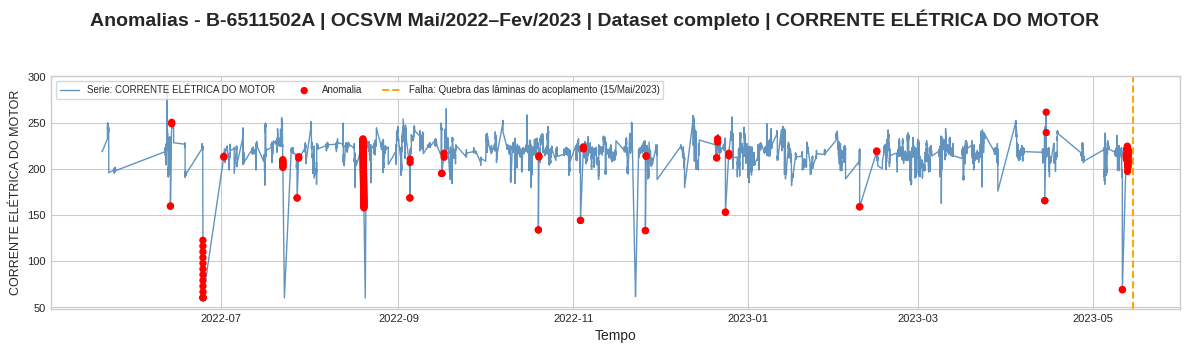

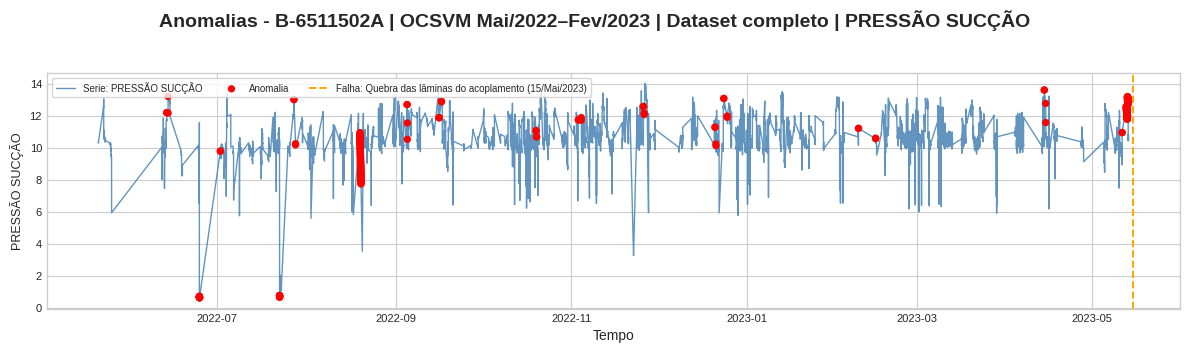

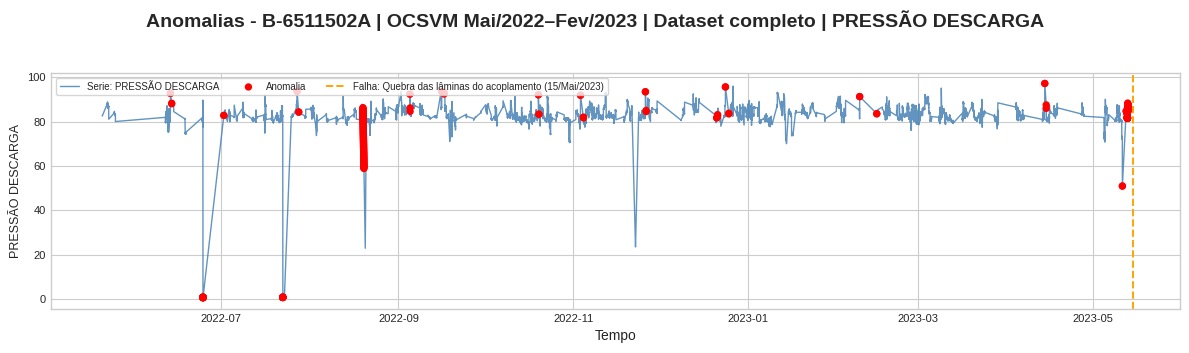

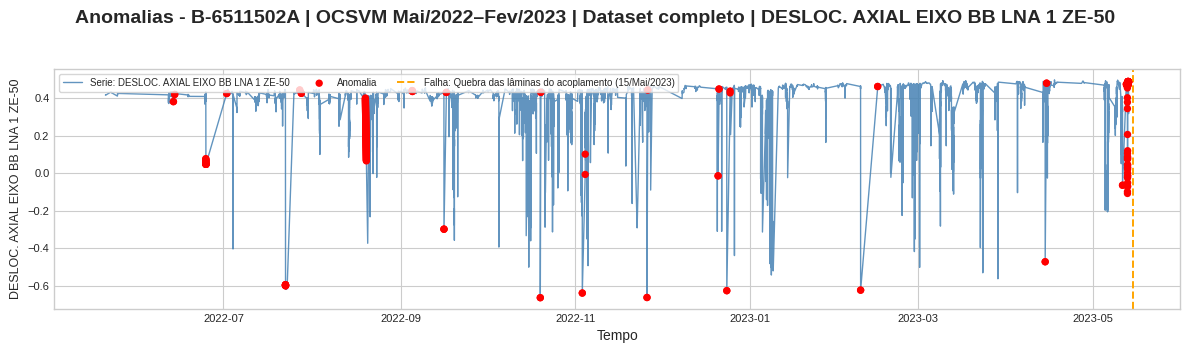

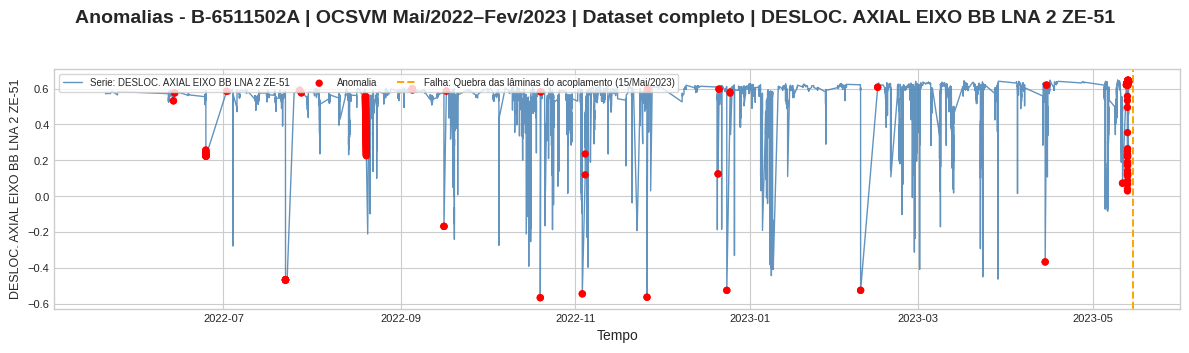

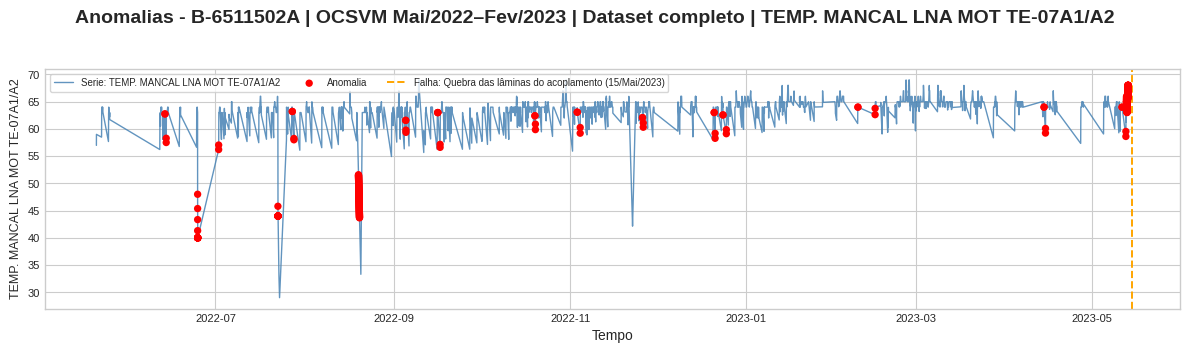

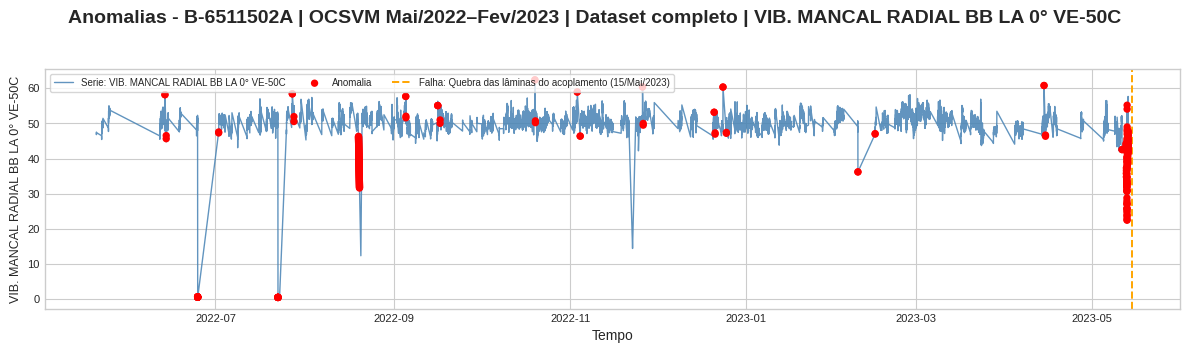

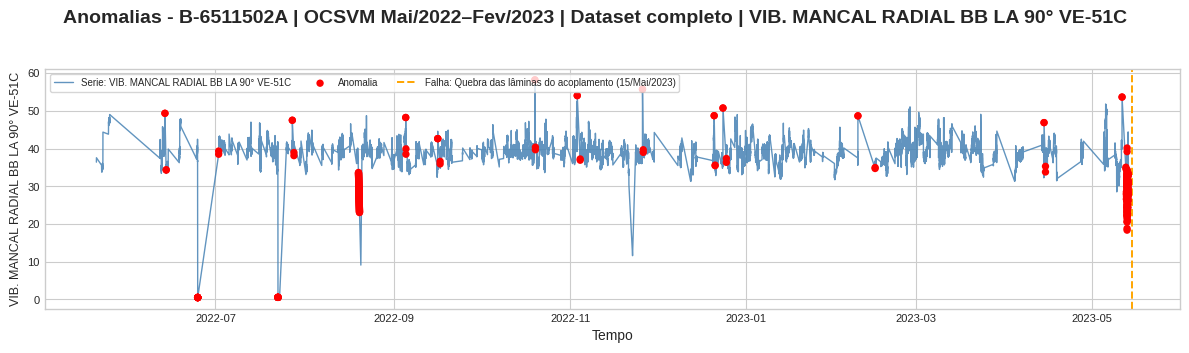

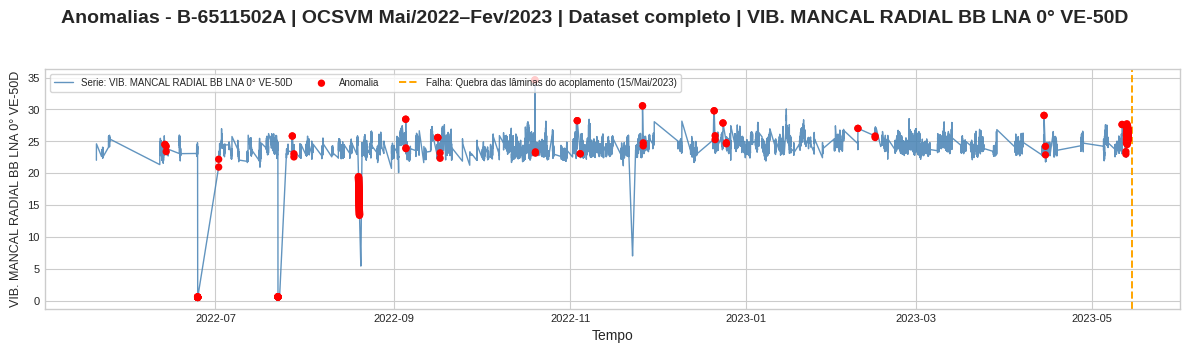

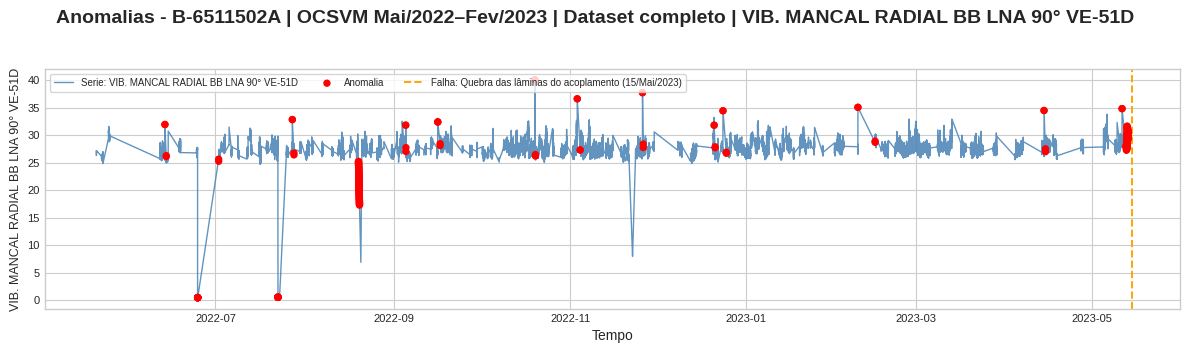

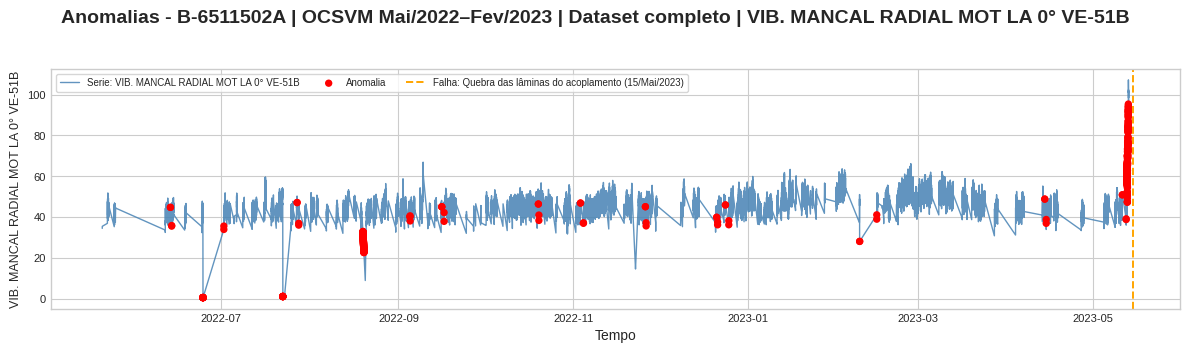

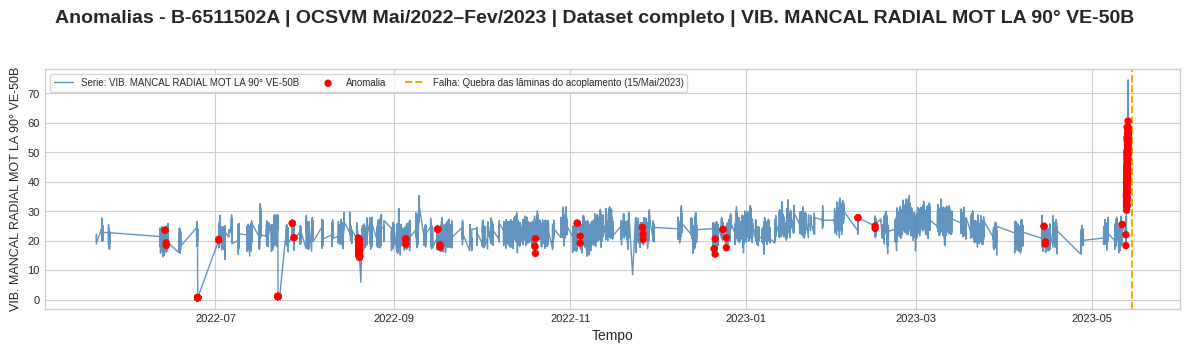

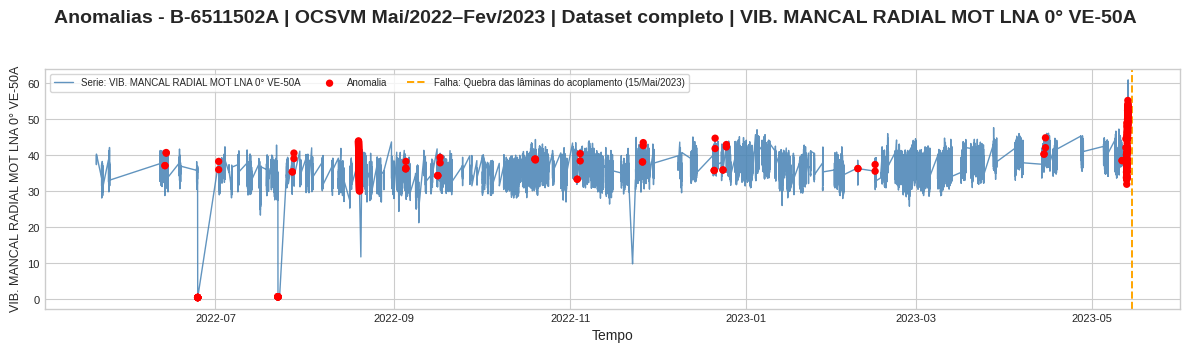

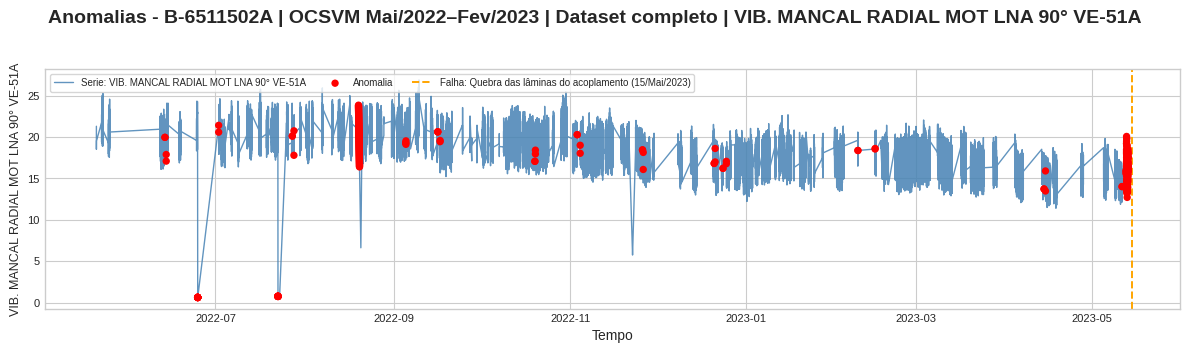

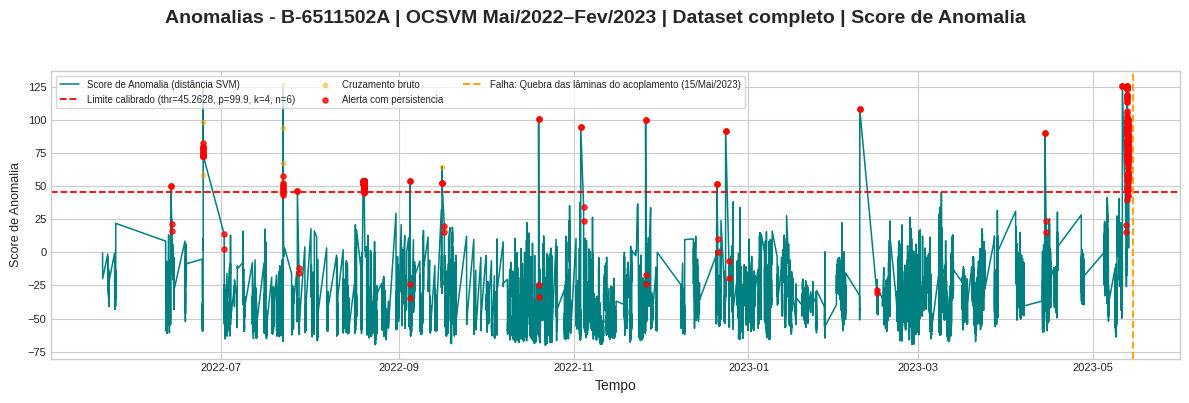

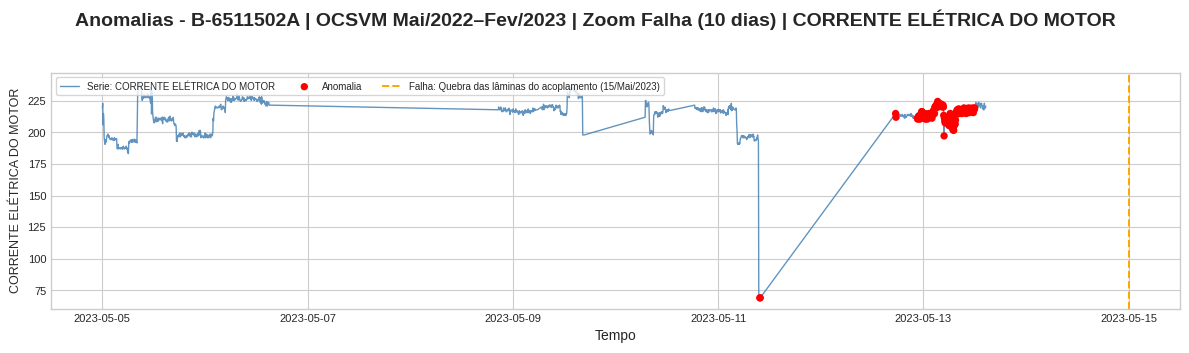

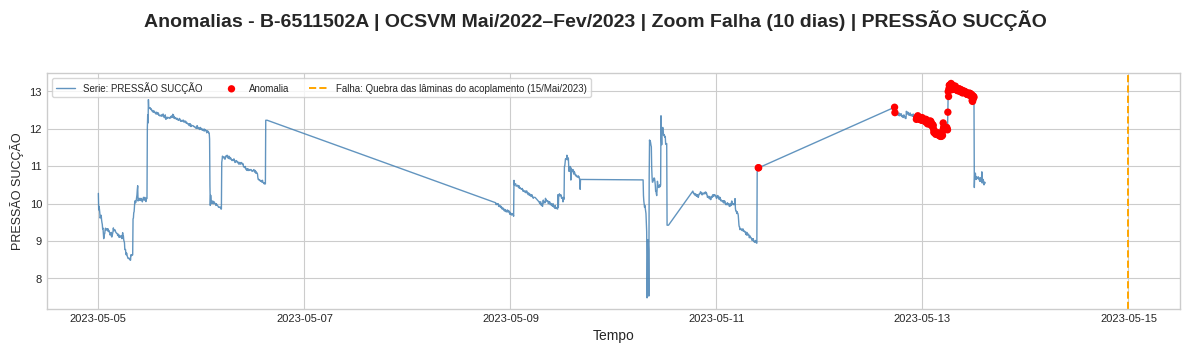

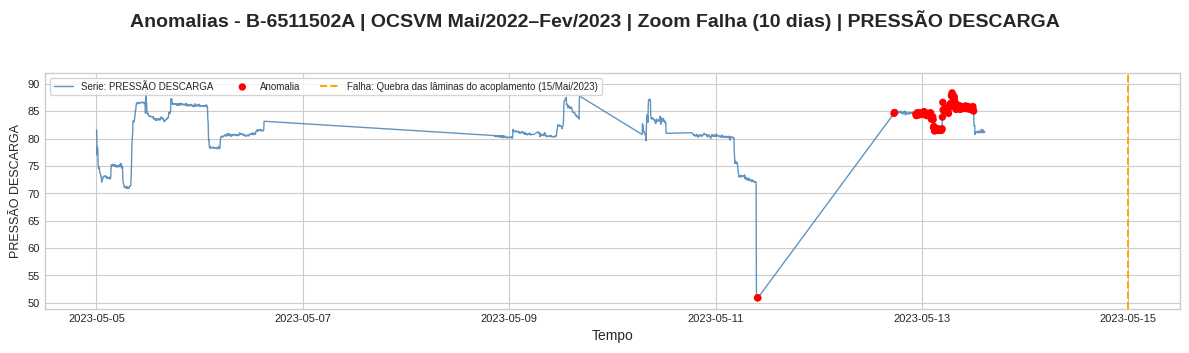

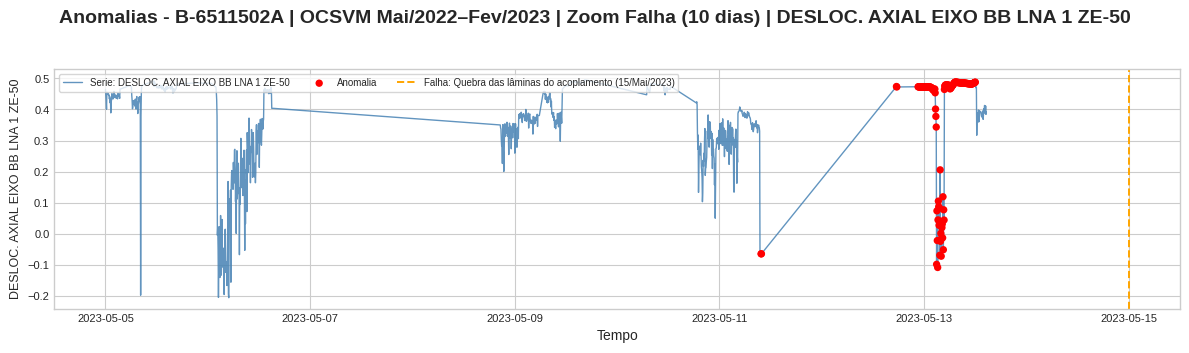

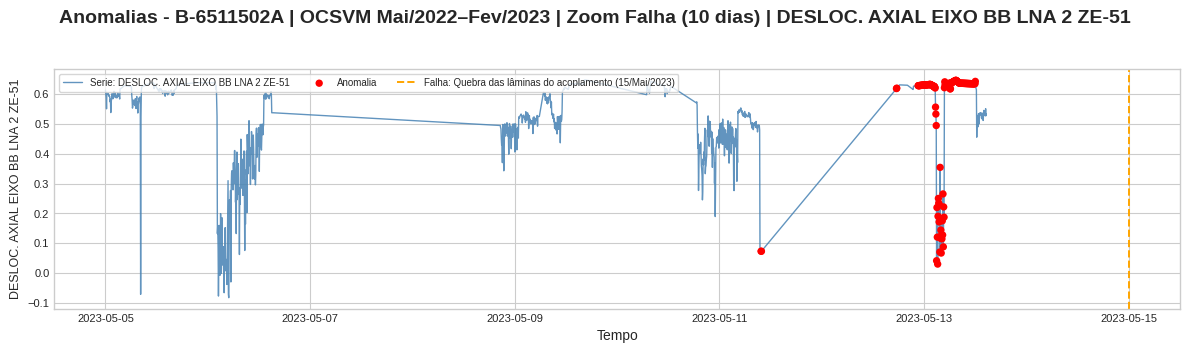

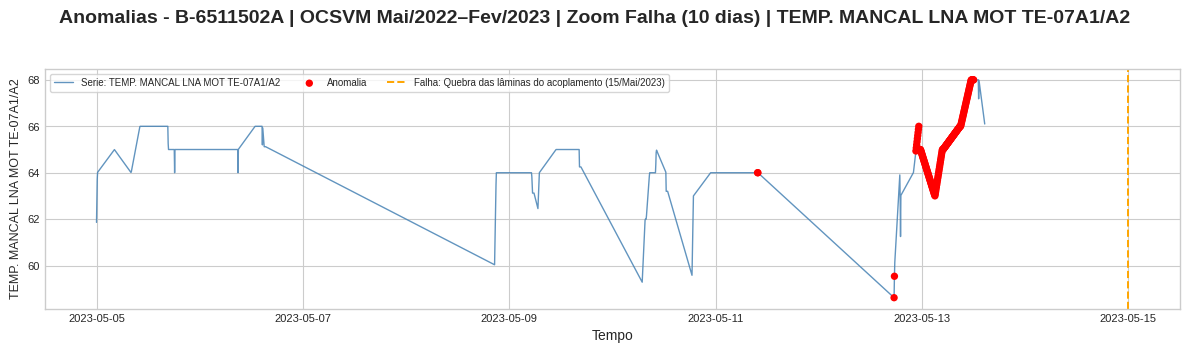

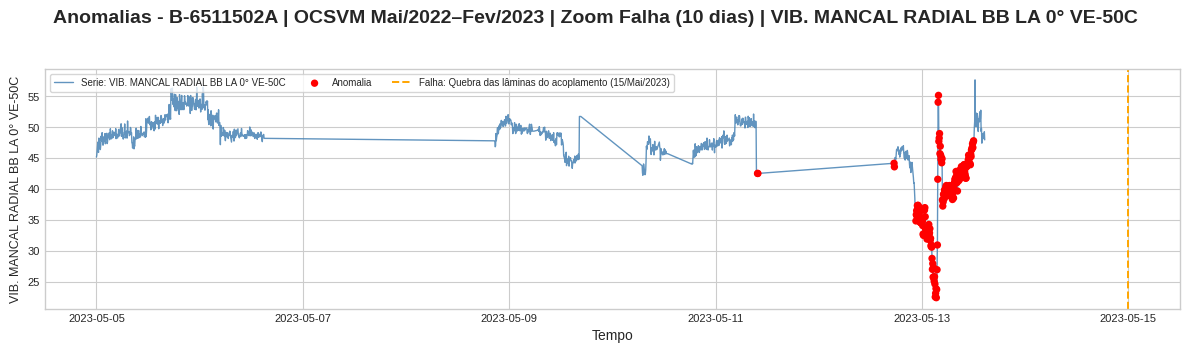

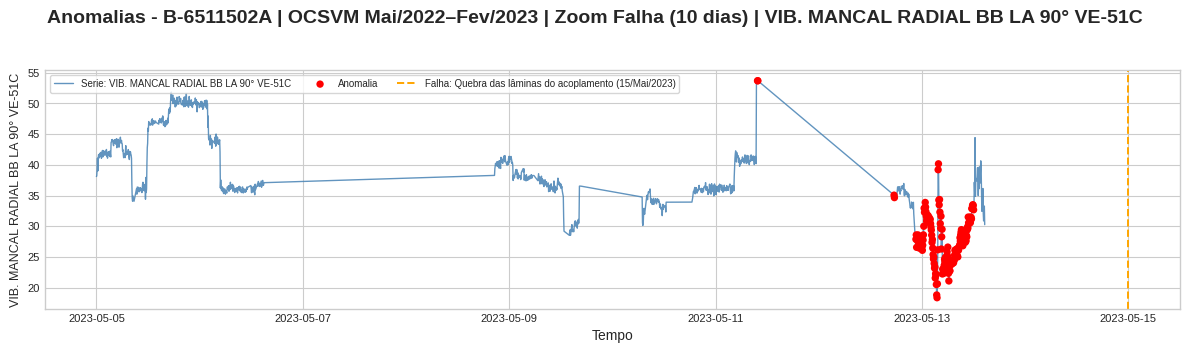

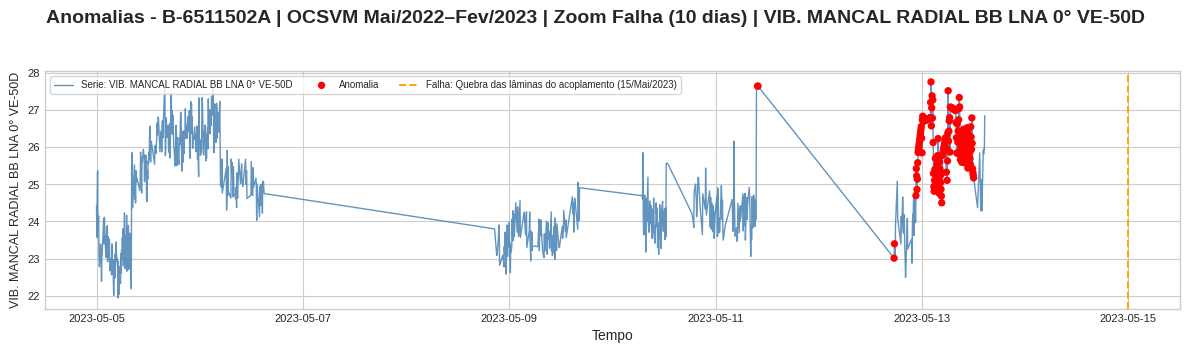

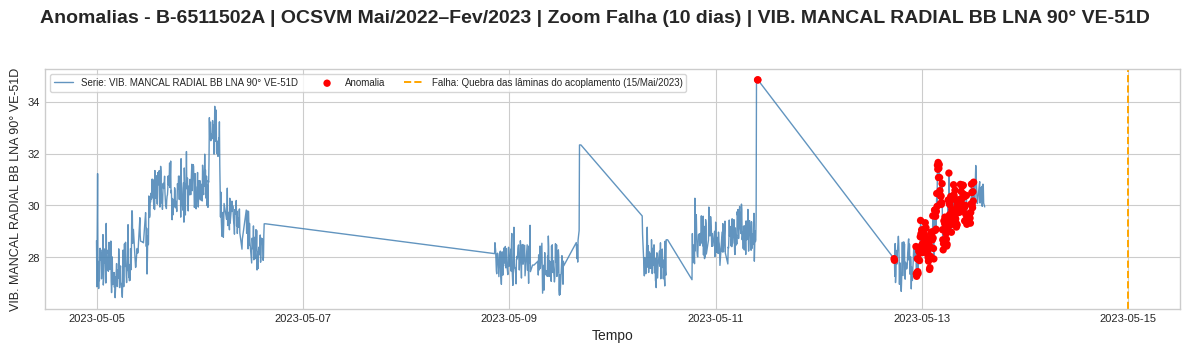

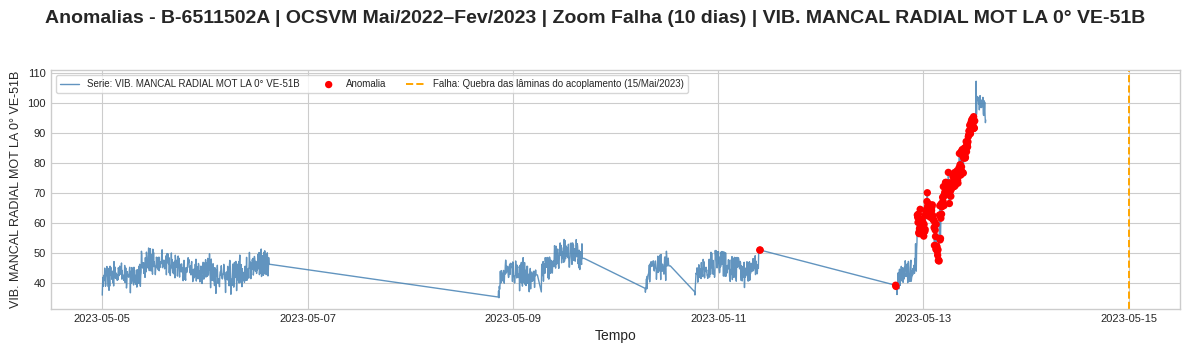

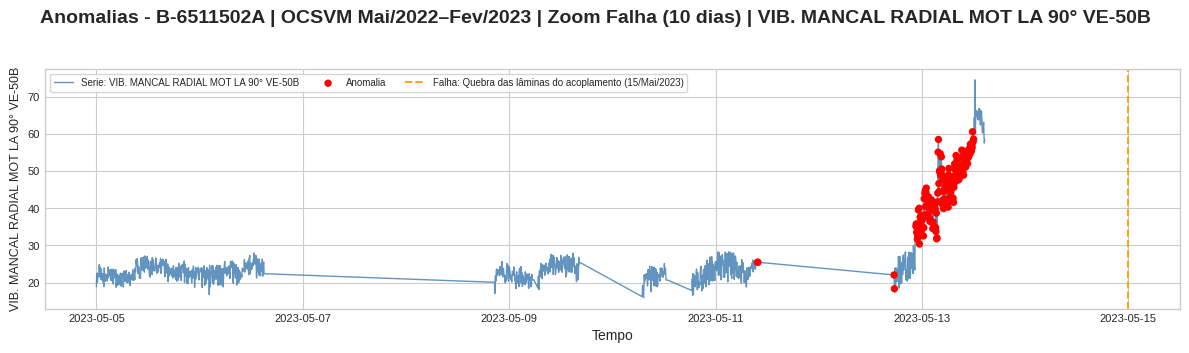

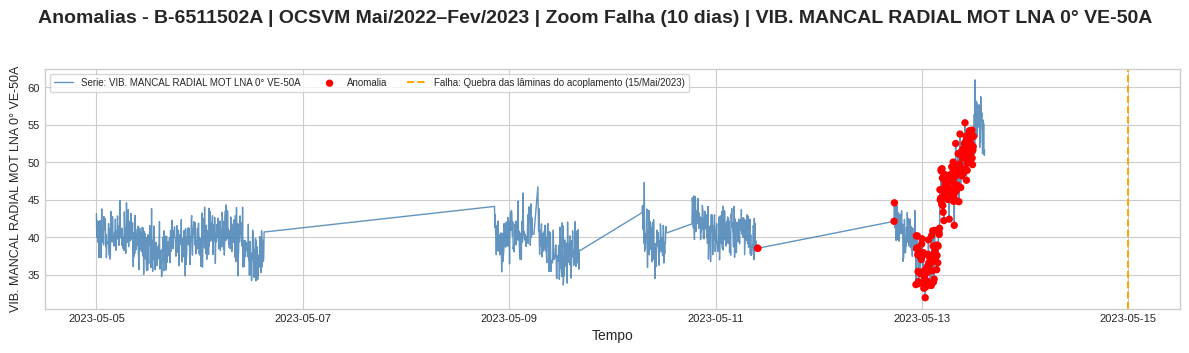

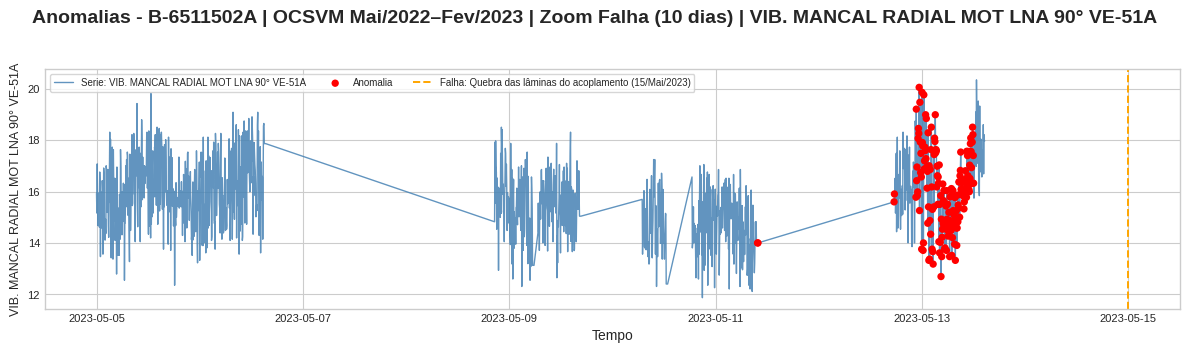

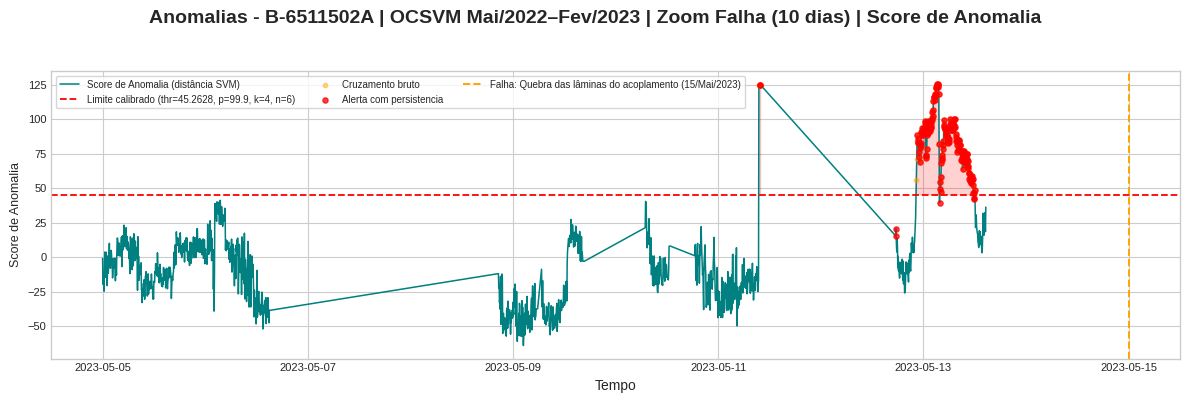

,janela,inicio,fim,n_samples,n_anomalies,pct_anomalies,threshold,k,n
0,Dataset completo,2022-05-20 17:20:00,2023-05-15,36387,339,0.93,45.262764,4,6
1,Zoom Falha (10 dias),2023-05-05 00:00:00,2023-05-15,1216,166,13.65,45.262764,4,6


In [6]:
safe_task_id = TASK_ID.replace('/', '_').replace(':', '_')

windows = [
    {
        'name': 'Dataset completo',
        'start': scores.index.min(),
        'end': EVENT_TS_F1,
        'event_date': EVENT_DATE_F1,
        'event_label': EVENT_LABEL_F1,
        'title': f'Anomalias - {EQUIPMENT_ID} | OCSVM Mai/2022–Fev/2023 | Dataset completo',
        'out': PROJECT_ROOT / 'reports' / f'anomalias_b6511502a_ocsvm_full_{safe_task_id}.png',
    },
    {
        'name': 'Zoom Falha (10 dias)',
        'start': WINDOW_F1_ZOOM_START,
        'end': WINDOW_F1_ZOOM_END,
        'event_date': EVENT_DATE_F1,
        'event_label': EVENT_LABEL_F1,
        'title': f'Anomalias - {EQUIPMENT_ID} | OCSVM Mai/2022–Fev/2023 | Zoom Falha (10 dias)',
        'out': PROJECT_ROOT / 'reports' / f'anomalias_b6511502a_ocsvm_zoom10_{safe_task_id}.png',
    },
]

summary_rows = []
for w in windows:
    df_window, scores_window = slice_window(df_base, scores, w['start'], w['end'])
    threshold_flags = scores_window['reconstruction_error'] > selected_threshold
    anomaly_flags = persistence_filter(threshold_flags, k=selected_k, n=selected_n)

    plot_anomaly_panels(
        df_window=df_window, scores_window=scores_window,
        threshold_flags=threshold_flags, anomaly_flags=anomaly_flags,
        threshold=selected_threshold, threshold_label=threshold_label,
        event_date=pd.Timestamp(w['event_date']), event_label=w['event_label'],
        title=w['title'], output_path=w['out'],
        dpi=OUTPUT_DPI, plot_mode=PLOT_MODE, save_plots=SAVE_PLOTS,
        score_label='Score de Anomalia (distância SVM)',
    )

    n_samples = len(scores_window)
    n_anom = int(anomaly_flags.sum())
    summary_rows.append({
        'janela': w['name'],
        'inicio': pd.Timestamp(w['start']),
        'fim': pd.Timestamp(w['end']),
        'n_samples': n_samples,
        'n_anomalies': n_anom,
        'pct_anomalies': round(100.0 * n_anom / n_samples, 2) if n_samples else 0.0,
        'threshold': selected_threshold,
        'k': selected_k,
        'n': selected_n,
    })

display(pd.DataFrame(summary_rows))